In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_numeric_std = StandardScaler().fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

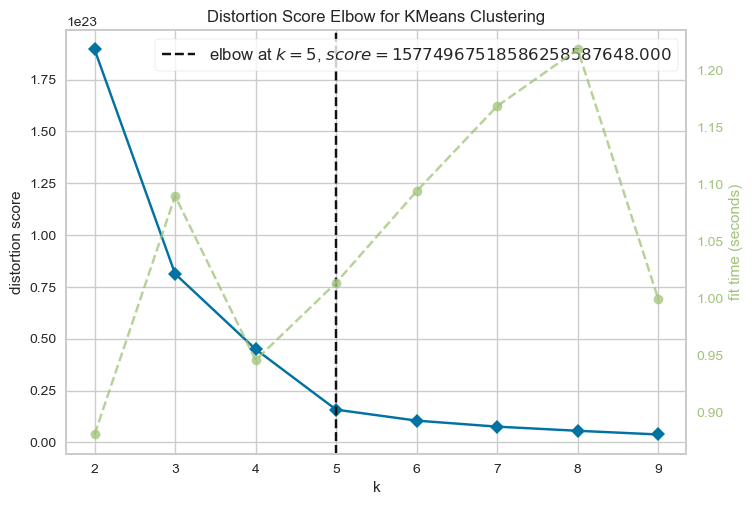

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: shape_VoxelVolume, Coefficient: 3.2035279212645484


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: glrlm_LowGrayLevelRunEmphasis_CT_c16, Coefficient: -3.249149376922999


...

Cluster 2: Most important feature: glcm_DifferenceVariance_d_1_PET_c04, Coefficient: 3.211117020794494


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: first_order_90Percentile_PET, Coefficient: 3.2986641579218015


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: glcm_Idmn_d_1_CT_b20, Coefficient: 1.7290714546109598


In [21]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,shape_VoxelVolume,glrlm_LowGrayLevelRunEmphasis_CT_c16,glcm_DifferenceVariance_d_1_PET_c04,first_order_90Percentile_PET,glcm_Idmn_d_1_CT_b20
0,16214.0,0.012892,0.231498,12.976912,0.998899
1,2863.0,0.012587,0.282292,5.631130,0.997145
2,28989.0,0.011590,0.220336,6.963644,0.998966
3,3337.0,0.007875,0.258319,2.937064,0.996870
4,5018.0,0.007317,0.298276,5.652872,0.992486
...,...,...,...,...,...
134,8321.0,0.006428,0.267836,8.774738,0.998705
135,25403.0,0.017201,0.218654,6.606596,0.999349
136,15322.0,0.012244,0.249174,12.128900,0.997995
137,18450.0,0.005961,0.246711,7.277164,0.999003


In [25]:
X_new_std

,shape_VoxelVolume,glrlm_LowGrayLevelRunEmphasis_CT_c16,glcm_DifferenceVariance_d_1_PET_c04,first_order_90Percentile_PET,glcm_Idmn_d_1_CT_b20
0,-0.264205,-0.155617,-0.301910,0.644250,0.559748
1,-0.663896,-0.169668,0.885381,-0.947354,-0.194275
2,0.118242,-0.215524,-0.562815,-0.658639,0.588636
3,-0.649706,-0.386393,0.325036,-1.531075,-0.312609
4,-0.599382,-0.412076,1.259000,-0.942643,-2.197808
...,...,...,...,...,...
134,-0.500499,-0.452967,0.547496,-0.266231,0.476323
135,0.010887,0.042598,-0.602134,-0.736001,0.753353
136,-0.290909,-0.185426,0.111270,0.460512,0.170946
137,-0.197266,-0.474439,0.053694,-0.590709,0.604694


In [26]:
MAASTRO_new

,shape_VoxelVolume,glrlm_LowGrayLevelRunEmphasis_CT_c16,glcm_DifferenceVariance_d_1_PET_c04,first_order_90Percentile_PET,glcm_Idmn_d_1_CT_b20
0,38115.0,0.007087,0.224600,14.076383,0.998387
1,17918.0,0.033669,0.209170,7.077812,0.998849
2,17475.0,0.008860,0.213618,11.123887,0.998010
3,12512.0,0.040380,0.215493,7.374829,0.996545
4,28361.0,0.010288,0.208412,8.358805,0.999547
...,...,...,...,...,...
94,12865.0,0.028215,0.227794,28.833381,0.998881
95,18413.0,0.026398,0.220185,11.134466,0.993218
96,35439.0,0.006561,0.195356,7.233497,0.998668
97,26221.0,0.010857,0.209642,11.935536,0.998942


In [27]:
MAASTRO_new_std

,shape_VoxelVolume,glrlm_LowGrayLevelRunEmphasis_CT_c16,glcm_DifferenceVariance_d_1_PET_c04,first_order_90Percentile_PET,glcm_Idmn_d_1_CT_b20
0,0.391448,-0.422626,-0.463143,0.882471,0.339754
1,-0.213192,0.800092,-0.823806,-0.633903,0.538162
2,-0.226455,-0.341105,-0.719840,0.242757,0.177449
3,-0.375033,1.108803,-0.676020,-0.569548,-0.452445
4,0.099441,-0.275381,-0.841521,-0.356351,0.838384
...,...,...,...,...,...
94,-0.364465,0.549214,-0.388487,4.079857,0.552225
95,-0.198373,0.465643,-0.566336,0.245049,-1.882786
96,0.311336,-0.446828,-1.146707,-0.600170,0.460541
97,0.035376,-0.249218,-0.812791,0.418616,0.578418


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 03:21:47,882] A new study created in memory with name: no-name-4a622cbd-eec9-4536-9bee-cb14ce188574


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6323529411764706
Fold 4 C-index: 0.759493670886076


[I 2024-04-18 03:21:49,140] A new study created in memory with name: no-name-5705a1c3-1984-4306-a614-fee850222d7d


Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:21:49,128] Trial 0 finished with value: 0.6785175603248318 and parameters: {}. Best is trial 0 with value: 0.6785175603248318.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6785175603248318], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 48, 296063), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 49, 127601), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6785175603248318


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23400351644777234
Fold 2 IBS: 0.1805116554891069
Fold 3 IBS: 0.18581839576731676
Fold 4 IBS: 0.19030253381132692
Fold 5 IBS: 0.21497844354517343
[I 2024-04-18 03:21:50,314] Trial 0 finished with value: 0.20112290901213928 and parameters: {}. Best is trial 0 with value: 0.20112290901213928.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20112290901213928], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 49, 274076), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 50, 314253), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20112290901213928


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.679
train_ibs:  0.201


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.588
IBS score: 0.215


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:21:50,955] A new study created in memory with name: no-name-473280bd-a6dd-4b88-8f8b-6c02d578960e


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.577922077922078
Fold 2 C-index: 0.7879464285714286
Fold 3 C-index: 0.6225490196078431


[I 2024-04-18 03:21:51,393] A new study created in memory with name: no-name-5b68cccf-7982-47f4-83b3-dc89eeeff03f


Fold 4 C-index: 0.6476793248945147
Fold 5 C-index: 0.6197183098591549
[I 2024-04-18 03:21:51,380] Trial 0 finished with value: 0.6511630321710038 and parameters: {}. Best is trial 0 with value: 0.6511630321710038.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6511630321710038], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 51, 17369), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 51, 380423), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6511630321710038


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651831574943
Fold 2 IBS: 0.2215779100038755
Fold 3 IBS: 0.2045359433238399
Fold 4 IBS: 0.2247380299115043
Fold 5 IBS: 0.218124313110162
[I 2024-04-18 03:21:52,166] Trial 0 finished with value: 0.21659054293302624 and parameters: {}. Best is trial 0 with value: 0.21659054293302624.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054293302624], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 51, 453537), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 52, 165888), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054293302624


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.651
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.585


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:21:52,830] A new study created in memory with name: no-name-7ccd6bde-c995-4a52-9ad8-33614d43e3d6


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7510548523206751


[I 2024-04-18 03:21:55,125] A new study created in memory with name: no-name-38caf243-4164-4278-aaa6-866bf8d1ce80


Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:21:55,091] Trial 0 finished with value: 0.6787905809254771 and parameters: {}. Best is trial 0 with value: 0.6787905809254771.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6787905809254771], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 52, 886293), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 55, 90454), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6787905809254771


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23301449756613274
Fold 2 IBS: 0.1813842896258467
Fold 3 IBS: 0.18575369276734266
Fold 4 IBS: 0.19027462561177869
Fold 5 IBS: 0.21454326203292076
[I 2024-04-18 03:21:56,989] Trial 0 finished with value: 0.2009940735208043 and parameters: {}. Best is trial 0 with value: 0.2009940735208043.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2009940735208043], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 55, 488528), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 56, 988662), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2009940735208043


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.679
train_ibs:  0.201


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.587


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.215


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:21:57,958] A new study created in memory with name: no-name-15867bda-2c41-4a6b-8657-1dec26b790ec


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:21:59,184] Trial 0 finished with value: 0.6787905809254771 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6787905809254771.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:22:00,763] Trial 1 finished with value: 0.6778101887686143 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6787905809254771.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6384976525821596
[I 2024-04-18 03:22:02,305] Trial 2 finished with value: 0.676822246346147 and parameters: {'l1_ratio': 0.22692876841884668}. 

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:22:32,355] Trial 24 finished with value: 0.679634462782017 and parameters: {'l1_ratio': 0.8735299120909291}. Best is trial 3 with value: 0.679634462782017.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:22:33,703] Trial 25 finished with value: 0.679634462782017 and parameters: {'l1_ratio': 0.7644349255539079}. Best is trial 3 with value: 0.679634462782017.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:22:35,925] Trial 26 finished with value: 0.6787905809254771 and parameters: {'l1_ratio': 0.6437885264645755}. Be

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:23:02,263] Trial 48 finished with value: 0.679634462782017 and parameters: {'l1_ratio': 0.7768768486379835}. Best is trial 3 with value: 0.679634462782017.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:23:03,261] Trial 49 finished with value: 0.679634462782017 and parameters: {'l1_ratio': 0.5751752392335482}. Best is trial 3 with value: 0.679634462782017.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.6384976525821596
[I 2024-04-18 03:23:04,241] Trial 50 finished with value: 0.6759783644896069 and parameters: {'l1_ratio': 0.2311229033161103}. Be

...

Fold 1 IBS: 0.2328505003918902
Fold 2 IBS: 0.18132169466942002
Fold 3 IBS: 0.1857427290046695
Fold 4 IBS: 0.19027811678351667
Fold 5 IBS: 0.21457154348498184
[I 2024-04-18 03:24:13,610] Trial 0 finished with value: 0.20095291686689562 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.20095291686689562.
Fold 1 IBS: 0.23268308833686976
Fold 2 IBS: 0.18117382351093292
Fold 3 IBS: 0.1857056783459178
Fold 4 IBS: 0.19028926928577183
Fold 5 IBS: 0.21466345253529698
[I 2024-04-18 03:24:15,297] Trial 1 finished with value: 0.20090306240295788 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.20090306240295788.
Fold 1 IBS: 0.23259060923570093
Fold 2 IBS: 0.18112757807978103
Fold 3 IBS: 0.18569439229650314
Fold 4 IBS: 0.1902927742280408
Fold 5 IBS: 0.21467793214794834
[I 2024-04-18 03:24:17,561] Trial 2 finished with value: 0.20087665719759484 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.2008766571975

Fold 1 IBS: 0.23267877873562867
Fold 2 IBS: 0.18122175094848061
Fold 3 IBS: 0.1857123219037925
Fold 4 IBS: 0.19028532252331312
Fold 5 IBS: 0.21461729326452864
[I 2024-04-18 03:24:57,171] Trial 25 finished with value: 0.2009030934751487 and parameters: {'l1_ratio': 0.3804525958179419}. Best is trial 22 with value: 0.20077299278196423.
Fold 1 IBS: 0.2326870124432809
Fold 2 IBS: 0.18115489877107294
Fold 3 IBS: 0.18570935263363467
Fold 4 IBS: 0.1902870526334788
Fold 5 IBS: 0.21464181933162998
[I 2024-04-18 03:24:59,237] Trial 26 finished with value: 0.20089602716261945 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 22 with value: 0.20077299278196423.
Fold 1 IBS: 0.23242203625562124
Fold 2 IBS: 0.1808323744422868
Fold 3 IBS: 0.18565308330622118
Fold 4 IBS: 0.19030994232220924
Fold 5 IBS: 0.2147824572718852
[I 2024-04-18 03:25:01,561] Trial 27 finished with value: 0.20079997871964475 and parameters: {'l1_ratio': 0.07046652721581821}. Best is trial 22 with value: 0.2007729927

Fold 5 IBS: 0.21457466931897987
[I 2024-04-18 03:25:38,277] Trial 49 finished with value: 0.2009637214208732 and parameters: {'l1_ratio': 0.7730065406479847}. Best is trial 45 with value: 0.2007588913581584.
Fold 1 IBS: 0.23237805136068942
Fold 2 IBS: 0.18093030856487693
Fold 3 IBS: 0.18566722679227513
Fold 4 IBS: 0.19030380005177056
Fold 5 IBS: 0.21472851077598823
[I 2024-04-18 03:25:39,881] Trial 50 finished with value: 0.20080157950912003 and parameters: {'l1_ratio': 0.11693829358733096}. Best is trial 45 with value: 0.2007588913581584.
Fold 1 IBS: 0.23226056367368034
Fold 2 IBS: 0.21879352916739592
Fold 3 IBS: 0.18564747757573855
Fold 4 IBS: 0.220462340305527
Fold 5 IBS: 0.21479987859720415
[I 2024-04-18 03:25:41,559] Trial 51 finished with value: 0.21439275786390918 and parameters: {'l1_ratio': 0.041899896096562146}. Best is trial 45 with value: 0.2007588913581584.
Fold 1 IBS: 0.2323083452379542
Fold 2 IBS: 0.18079182159169088
Fold 3 IBS: 0.18565374729637246
Fold 4 IBS: 0.19031270

Fold 1 IBS: 0.23239245230824496
Fold 2 IBS: 0.18081394928228078
Fold 3 IBS: 0.18564944686881324
Fold 4 IBS: 0.19031134747973874
Fold 5 IBS: 0.21478840906012564
[I 2024-04-18 03:26:17,750] Trial 74 finished with value: 0.20079112099984067 and parameters: {'l1_ratio': 0.06215903205951262}. Best is trial 45 with value: 0.2007588913581584.
Fold 1 IBS: 0.21324486295599646
Fold 2 IBS: 0.22010137457260948
Fold 3 IBS: 0.20373686634017157
Fold 4 IBS: 0.22242463713381389
Fold 5 IBS: 0.21482945516430083
[I 2024-04-18 03:26:18,729] Trial 75 finished with value: 0.21486743923337842 and parameters: {'l1_ratio': 0.021381120724883997}. Best is trial 45 with value: 0.2007588913581584.
Fold 1 IBS: 0.23244687802722305
Fold 2 IBS: 0.18089706734745792
Fold 3 IBS: 0.1856609015860831
Fold 4 IBS: 0.1903049492869247
Fold 5 IBS: 0.2147447705005489
[I 2024-04-18 03:26:20,501] Trial 76 finished with value: 0.20081091334964754 and parameters: {'l1_ratio': 0.11036884839248226}. Best is trial 45 with value: 0.200758

Fold 5 IBS: 0.21470566685276185
[I 2024-04-18 03:26:58,271] Trial 98 finished with value: 0.20083083846585786 and parameters: {'l1_ratio': 0.15926120393133159}. Best is trial 45 with value: 0.2007588913581584.
Fold 1 IBS: 0.21394316380859946
Fold 2 IBS: 0.22151196448519414
Fold 3 IBS: 0.20449929467513073
Fold 4 IBS: 0.22463263321133534
Fold 5 IBS: 0.21810463388954754
[I 2024-04-18 03:26:58,978] Trial 99 finished with value: 0.21653833801396144 and parameters: {'l1_ratio': 0.0009197457918937099}. Best is trial 45 with value: 0.2007588913581584.


* Best trial for IBS: 
 FrozenTrial(number=45, state=TrialState.COMPLETE, values=[0.2007588913581584], datetime_start=datetime.datetime(2024, 4, 18, 3, 25, 30, 14028), datetime_complete=datetime.datetime(2024, 4, 18, 3, 25, 31, 693777), params={'l1_ratio': 0.046354499215697016}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=45, value=No

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.68
train_ibs:  0.201


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.5513596376059829)

test_cindex : 0.587


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.046354499215697016)

test_ibs:  0.215


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 03:26:59,770] A new study created in memory with name: no-name-68b9a7cf-e3e6-4408-bb19-152da2ccb7ca


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.7130801687763713
Fold 5 C-index: 0.6056338028169014
[I 2024-04-18 03:27:19,902] Trial 0 finished with value: 0.6604148722407325 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6604148722407325.
Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.6274509803921569
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.5539906103286385
[I 2024-04-18 03:27:32,493] Trial 1 finished with value: 0.6381548587765224 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 03:29:46,573] Trial 15 finished with value: 0.5 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 48, 'oob_score': True, 'max_samples': 0.858152651635632, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.4533275126681895, 'warm_start': True}. Best is trial 14 with value: 0.689506254312127.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 03:29:49,963] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.8301569762996464, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.4285489292377008, 'warm_start': True}. Best is trial 14 with value: 0.689506254312127.
Fold 1 C-index: 0.6471861471861472
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.68872549019

Fold 1 C-index: 0.5432900432900433
Fold 2 C-index: 0.8638392857142857
Fold 3 C-index: 0.7254901960784313
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.7605633802816901
[I 2024-04-18 03:30:27,394] Trial 31 finished with value: 0.7448813068112867 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 16, 'min_samples_leaf': 9, 'max_depth': 16, 'n_estimators': 24, 'oob_score': True, 'max_samples': 0.944753423986914, 'max_features': None, 'min_weight_fraction_leaf': 0.06898006166387718, 'warm_start': True}. Best is trial 30 with value: 0.7481931814890335.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.8616071428571429
Fold 3 C-index: 0.7647058823529411
Fold 4 C-index: 0.8438818565400844
Fold 5 C-index: 0.7652582159624414
[I 2024-04-18 03:30:28,813] Trial 32 finished with value: 0.7570473294992319 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 42, 'oob_score': True, 'max_samples': 0.9382857616623193, 'm

...

Fold 1 IBS: 0.2064323148404713
Fold 2 IBS: 0.19186026140358883
Fold 3 IBS: 0.19043641657381563
Fold 4 IBS: 0.18858799002508023
Fold 5 IBS: 0.23001491124785023
[I 2024-04-18 03:43:37,676] Trial 32 finished with value: 0.2014663788181612 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 15, 'max_depth': 9, 'n_estimators': 368, 'oob_score': False, 'max_samples': 0.9322436001381669, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.14340411971529166}. Best is trial 6 with value: 0.20109938069910022.
Fold 1 IBS: 0.20838976514221286
Fold 2 IBS: 0.19161322338973083
Fold 3 IBS: 0.19021128582651253
Fold 4 IBS: 0.18947332911063314
Fold 5 IBS: 0.23170968108972045
[I 2024-04-18 03:43:51,620] Trial 33 finished with value: 0.202279456911762 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 5, 'n_estimators': 368, 'oob_score': False, 'max_samples': 0.7918580074542103, 'max_features': 'auto', 'min_weight_fraction_

Fold 5 IBS: 0.2356841580661291
[I 2024-04-18 03:47:07,894] Trial 47 finished with value: 0.20532930955391665 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 17, 'max_depth': 14, 'n_estimators': 272, 'oob_score': False, 'max_samples': 0.8252659010917025, 'max_features': None, 'min_weight_fraction_leaf': 0.16491276307910185}. Best is trial 6 with value: 0.20109938069910022.
Fold 1 IBS: 0.2109456795855575
Fold 2 IBS: 0.19232297187889497
Fold 3 IBS: 0.18904250249168741
Fold 4 IBS: 0.19979907439062564
Fold 5 IBS: 0.22741116411059928
[I 2024-04-18 03:47:21,112] Trial 48 finished with value: 0.20390427849147294 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 3, 'n_estimators': 329, 'oob_score': False, 'max_samples': 0.9993511027834792, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.30756770058102956}. Best is trial 6 with value: 0.20109938069910022.
Fold 1 IBS: 0.2084118296861316
Fold 2 IBS: 0.186049

Fold 1 IBS: 0.20442486767328083
Fold 2 IBS: 0.179658840858241
Fold 3 IBS: 0.17984203686782446
Fold 4 IBS: 0.19595597510385226
Fold 5 IBS: 0.24154903238703496
[I 2024-04-18 03:50:50,077] Trial 63 finished with value: 0.20028615057804666 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 19, 'max_depth': 17, 'n_estimators': 475, 'oob_score': False, 'max_samples': 0.8986434991412128, 'max_features': None, 'min_weight_fraction_leaf': 0.3992534217162943}. Best is trial 61 with value: 0.2000342049772069.
Fold 1 IBS: 0.20443830742636904
Fold 2 IBS: 0.17958931260993713
Fold 3 IBS: 0.179800142981048
Fold 4 IBS: 0.19598246863883176
Fold 5 IBS: 0.24104555170128997
[I 2024-04-18 03:51:09,625] Trial 64 finished with value: 0.20017115667149515 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 19, 'max_depth': 17, 'n_estimators': 478, 'oob_score': False, 'max_samples': 0.8996363839612884, 'max_features': None, 'min_weight_fraction_leaf'

Fold 1 IBS: 0.21396983887758947
Fold 2 IBS: 0.2207175663000269
Fold 3 IBS: 0.2049326079439446
Fold 4 IBS: 0.22480371221264672
Fold 5 IBS: 0.2171416967203181
[I 2024-04-18 03:55:32,756] Trial 79 finished with value: 0.2163130844109052 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 18, 'max_depth': 20, 'n_estimators': 445, 'oob_score': False, 'max_samples': 0.12074719353470553, 'max_features': None, 'min_weight_fraction_leaf': 0.3983705161725977}. Best is trial 74 with value: 0.19915017961410791.
Fold 1 IBS: 0.21398190650503598
Fold 2 IBS: 0.22129476058901895
Fold 3 IBS: 0.20479505946138896
Fold 4 IBS: 0.22462521232687563
Fold 5 IBS: 0.2185847047904264
[I 2024-04-18 03:55:47,248] Trial 80 finished with value: 0.21665632873454918 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 20, 'max_depth': 16, 'n_estimators': 411, 'oob_score': False, 'max_samples': 0.7989643083601817, 'max_features': None, 'min_weight_fraction_leaf

Fold 1 IBS: 0.21398172803793059
Fold 2 IBS: 0.22134628329994663
Fold 3 IBS: 0.20479662858568481
Fold 4 IBS: 0.22464439384005203
Fold 5 IBS: 0.21860612052486333
[I 2024-04-18 04:00:23,670] Trial 95 finished with value: 0.21667503085769546 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 19, 'max_depth': 19, 'n_estimators': 450, 'oob_score': True, 'max_samples': 0.86238186351905, 'max_features': None, 'min_weight_fraction_leaf': 0.434253141439349}. Best is trial 83 with value: 0.19909043993083286.
Fold 1 IBS: 0.20347987127300257
Fold 2 IBS: 0.18794775235627253
Fold 3 IBS: 0.18475846279613692
Fold 4 IBS: 0.20167471375816887
Fold 5 IBS: 0.23429291991489604
[I 2024-04-18 04:00:44,430] Trial 96 finished with value: 0.20243074401969538 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 4, 'min_samples_leaf': 18, 'max_depth': 15, 'n_estimators': 490, 'oob_score': True, 'max_samples': 0.832636370337404, 'max_features': None, 'min_weight_fraction_leaf': 

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.824
train_ibs:  0.199


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=12, max_features=None, max_leaf_nodes=18,
                     max_samples=0.7839595288977597, min_samples_leaf=1,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.0011167294528342253,
                     n_estimators=367, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.557


RandomSurvivalForest(max_depth=17, max_features=None, max_leaf_nodes=2,
                     max_samples=0.921468169574945, min_samples_leaf=19,
                     min_samples_split=10,
                     min_weight_fraction_leaf=0.4571560205172705,
                     n_estimators=394, random_state=123)

test_ibs:  0.214


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 04:01:46,750] A new study created in memory with name: no-name-cebaa19c-1f66-40a4-92a2-de81788f4287


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.6877637130801688
Fold 5 C-index: 0.6572769953051644
[I 2024-04-18 04:01:49,414] Trial 0 finished with value: 0.6929099751377236 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6929099751377236.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:01:56,514] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 1 C-index: 0.5735930735930735
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.6446078431372549
Fold 4 C-index: 0.6708860759493671
Fold 5 C-index: 0.6103286384976526
[I 2024-04-18 04:03:10,013] Trial 15 finished with value: 0.6668474119497553 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7013973166942266.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.8526785714285714
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.7067510548523207
Fold 5 C-index: 0.5328638497652582
[I 2024-04-18 04:03:14,251] Trial 16 finished with value: 0.6807326957185247 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_feat

Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.7341772151898734
Fold 5 C-index: 0.6666666666666666
[I 2024-04-18 04:04:09,225] Trial 30 finished with value: 0.7019952342271776 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 404, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6268142217016631, 'min_weight_fraction_leaf': 0.03868084640768137}. Best is trial 30 with value: 0.7019952342271776.
Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6666666666666666
[I 2024-04-18 04:04:12,697] Trial 31 finished with value: 0.7019462589408605 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 409, 'oob_score': False, 'warm_start': True, 'max_fea

...

Fold 1 IBS: 0.2122421798032124
Fold 2 IBS: 0.21029581242051235
Fold 3 IBS: 0.2006826481263743
Fold 4 IBS: 0.21732094567074203
Fold 5 IBS: 0.21499442233983285
[I 2024-04-18 04:14:33,974] Trial 30 finished with value: 0.2111072016721348 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 62, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.5897285086805036, 'min_weight_fraction_leaf': 0.10310563679536389}. Best is trial 26 with value: 0.20532859805736434.
Fold 1 IBS: 0.2061947108903838
Fold 2 IBS: 0.2037635635631119
Fold 3 IBS: 0.1934751870671824
Fold 4 IBS: 0.20285114041560848
Fold 5 IBS: 0.21732695423866263
[I 2024-04-18 04:14:44,501] Trial 31 finished with value: 0.20472231123498985 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 317, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.82

Fold 1 IBS: 0.2073679212335801
Fold 2 IBS: 0.1948927300978326
Fold 3 IBS: 0.18965301336913354
Fold 4 IBS: 0.19178240779389402
Fold 5 IBS: 0.2198640758221092
[I 2024-04-18 04:16:55,965] Trial 45 finished with value: 0.2007120296633099 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 6, 'max_depth': 15, 'n_estimators': 139, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9974910493739932, 'min_weight_fraction_leaf': 0.02697241782709868}. Best is trial 32 with value: 0.1998393818162469.
Fold 1 IBS: 0.2078346194557145
Fold 2 IBS: 0.21040450670006514
Fold 3 IBS: 0.19850384900266568
Fold 4 IBS: 0.21321281998177316
Fold 5 IBS: 0.21873164431656697
[I 2024-04-18 04:17:01,918] Trial 46 finished with value: 0.2097374878913571 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 15, 'n_estimators': 138, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.9854284

Fold 1 IBS: 0.2042140447625256
Fold 2 IBS: 0.19331395074201385
Fold 3 IBS: 0.19203024799825072
Fold 4 IBS: 0.19451469362137805
Fold 5 IBS: 0.21930785342537207
[I 2024-04-18 04:19:12,648] Trial 60 finished with value: 0.20067615810990808 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 19, 'n_estimators': 185, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9625508813326412, 'min_weight_fraction_leaf': 0.057403583208644124}. Best is trial 51 with value: 0.19949126816069623.
Fold 1 IBS: 0.2067507134398501
Fold 2 IBS: 0.19278403603264918
Fold 3 IBS: 0.19196100773885227
Fold 4 IBS: 0.1919382810682469
Fold 5 IBS: 0.22031491690517105
[I 2024-04-18 04:19:21,361] Trial 61 finished with value: 0.20074979103695387 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 206, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.

Fold 1 IBS: 0.20577368156178466
Fold 2 IBS: 0.19724616442941986
Fold 3 IBS: 0.19427128874376345
Fold 4 IBS: 0.20097147595516035
Fold 5 IBS: 0.21669239479974223
[I 2024-04-18 04:21:26,764] Trial 75 finished with value: 0.20299100109797408 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 15, 'n_estimators': 244, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8039301632568356, 'min_weight_fraction_leaf': 0.11682354502175389}. Best is trial 51 with value: 0.19949126816069623.
Fold 1 IBS: 0.20512454836544278
Fold 2 IBS: 0.19403430319047835
Fold 3 IBS: 0.19352160029415488
Fold 4 IBS: 0.19345683937053101
Fold 5 IBS: 0.219177680915479
[I 2024-04-18 04:21:34,260] Trial 76 finished with value: 0.20106299442721723 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 16, 'min_samples_leaf': 7, 'max_depth': 13, 'n_estimators': 183, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.

Fold 1 IBS: 0.21375050369604426
Fold 2 IBS: 0.18961808238754826
Fold 3 IBS: 0.18752366002490478
Fold 4 IBS: 0.182025187285147
Fold 5 IBS: 0.22539335954538797
[I 2024-04-18 04:22:35,772] Trial 90 finished with value: 0.19966215858780648 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 75, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.5525058622907164, 'min_weight_fraction_leaf': 0.008401626057697634}. Best is trial 81 with value: 0.19786663915353112.
Fold 1 IBS: 0.20939895122455057
Fold 2 IBS: 0.18734262626036002
Fold 3 IBS: 0.19062421489175643
Fold 4 IBS: 0.1846070022597126
Fold 5 IBS: 0.22481601349218447
[I 2024-04-18 04:22:39,516] Trial 91 finished with value: 0.1993577616257128 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 76, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.55567

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.73
train_ibs:  0.195


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=4, max_features=None, max_leaf_nodes=9,
                   max_samples=0.9443112973024967, min_samples_split=13,
                   min_weight_fraction_leaf=0.028359887769198316,
                   n_estimators=355, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.591


ExtraSurvivalTrees(max_depth=20, max_features=None, max_leaf_nodes=19,
                   max_samples=0.44440044238331455, min_samples_leaf=4,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.02617407726505743, n_estimators=4,
                   oob_score=True, random_state=123)

IBS: 0.222


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 04:22:58,945] A new study created in memory with name: no-name-c671e6f0-e047-4349-8485-3c5ba2246f8c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:24:04,325] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:24:39,134] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:42:46,500] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.652826665622245.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:45:10,034] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squared

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 05:12:57,930] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.3509209656285343, 'max_features': 1, 'min_impurity_decrease': 2.941022248196409e-06, 'validation_fraction': 0.9367695063592092, 'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 13, 'max_depth': 19}. Best is trial 9 with value: 0.652826665622245.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 05:15:56,387] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.28451691271554613, 'learning_rate': 0.05452181969732228, 'dropout_rate': 0.4224088852960579, 'n_estimators': 499, 'criterion': 'squared_error'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-18 06:55:05,109] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.21649333967056159.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-18 06:56:05,502] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsa

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-18 07:03:03,093] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.21649333967056159.
Fold 1 IBS: 0.2137713594489828
Fold 2 IBS: 0.22144126753151483
Fold 3 IBS: 0.20418592583067496
Fold 4 IBS: 0.22445519385172852
Fold 5 IBS: 0.2182170003774284
[I 2024-04-18 07:03:35,410] Trial 57 finished with value: 0.2164141494080659 and parameters: {'subsample': 0.553868700002313, 'le

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-18 07:14:17,617] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.2159309663576292.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-18 07:15:35,414] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 'learning_rate': 0.07904961819884

Fold 4 IBS: 0.22374377763109596
Fold 5 IBS: 0.21828892790538298
[I 2024-04-18 07:24:50,442] Trial 78 finished with value: 0.2158946854623728 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.21569366981461865.
Fold 1 IBS: 0.213520034119596
Fold 2 IBS: 0.22052947264213824
Fold 3 IBS: 0.20368982975204836
Fold 4 IBS: 0.223838321740976
Fold 5 IBS: 0.21830540676725219
[I 2024-04-18 07:25:11,715] Trial 79 finished with value: 0.2159766130044022 and parameters: {'subsample': 0.33166032751272273, 'learning_rate': 0.07500771068641232, 'dropout_rate': 0.95915144

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-18 07:30:33,603] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.40845912170347753, 'learning_rate': 0.07409455257113193, 'dropout_rate': 0.9031580025226588, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 1.426169496743956, 'min_weight_fraction_leaf': 0.17670307432796536, 'max_features': 'log2', 'min_impurity_decrease': 0.001833888378396466, 'validation_fraction': 0.7135149436193794, 'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 3}. Best is trial 85 with value: 0.21569290318586115.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812559182233554
[I 2024-04-18 07:31:16,710] Trial 90 finished with value: 0.21659080393566382 and parameters: {'subsample': 0.2452119153654136, 'learning_rate': 0.06690965498406037, 'dropout_rate': 0.8066291

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.675
train_ibs:  0.216


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03710606902460499,
                                 dropout_rate=0.9019406028516623,
                                 learning_rate=0.0797433994002493, max_depth=15,
                                 max_features='sqrt', max_leaf_nodes=17,
                                 min_impurity_decrease=4.622343656719489e-05,
                                 min_samples_leaf=19, min_samples_split=8,
                                 min_weight_fraction_leaf=0.14235013403546368,
                                 n_estimators=258, random_state=123,
                                 subsample=0.6307630032474463,
                                 validation_fraction=0.3406032150791013)

C-index score: 0.591


GradientBoostingSurvivalAnalysis(ccp_alpha=0.011442347425600019,
                                 criterion='squared_error',
                                 dropout_rate=0.8650736182476468,
                                 learning_rate=0.0870188009772593, max_depth=4,
                                 max_features='log2', max_leaf_nodes=15,
                                 min_impurity_decrease=0.0023183056456774986,
                                 min_samples_leaf=10, min_samples_split=18,
                                 min_weight_fraction_leaf=0.20755679443331537,
                                 n_estimators=400, random_state=123,
                                 subsample=0.33629527130521414,
                                 validation_fraction=0.611401083754954)

IBS: 0.22


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 07:38:23,569] A new study created in memory with name: no-name-3f422f1b-e8ad-48b3-b1a5-c799776143ca


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.5882352941176471
Fold 4 C-index: 0.6244725738396625
Fold 5 C-index: 0.6197183098591549
[I 2024-04-18 07:38:25,616] Trial 0 finished with value: 0.6397265775546349 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6397265775546349.
Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.5882352941176471
Fold 4 C-index: 0.620253164556962
Fold 5 C-index: 0.6150234741784038
[I 2024-04-18 07:38:45,125] Trial 1 finished with value: 0.6396753302935464 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6397265775546349.
Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.6029411764705882
Fold 4

Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6078431372549019
Fold 4 C-index: 0.6455696202531646
Fold 5 C-index: 0.6103286384976526
[I 2024-04-18 07:41:27,728] Trial 19 finished with value: 0.6485870237898884 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.9965556284420156, 'n_estimators': 431, 'learning_rate': 0.0777103409259433}. Best is trial 18 with value: 0.6522136528074334.
Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6176470588235294
Fold 4 C-index: 0.6540084388185654
Fold 5 C-index: 0.6056338028169014
[I 2024-04-18 07:41:39,991] Trial 20 finished with value: 0.6486992020831412 and parameters: {'subsample': 0.22039459654553953, 'dropout_rate': 0.8107159105319969, 'n_estimators': 420, 'learning_rate': 0.0644683878889867}. Best is trial 18 with value: 0.6522136528074334.
Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6127450980392157
F

Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5980392156862745
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6009389671361502
[I 2024-04-18 07:45:14,511] Trial 38 finished with value: 0.6421457653386644 and parameters: {'subsample': 0.5630145939578994, 'dropout_rate': 0.8542454664817839, 'n_estimators': 338, 'learning_rate': 0.06056395811680432}. Best is trial 18 with value: 0.6522136528074334.
Fold 1 C-index: 0.5714285714285714
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6176470588235294
Fold 4 C-index: 0.6540084388185654
Fold 5 C-index: 0.6103286384976526
[I 2024-04-18 07:45:17,301] Trial 39 finished with value: 0.6505039700850923 and parameters: {'subsample': 0.33669789584858295, 'dropout_rate': 0.7402602654042145, 'n_estimators': 145, 'learning_rate': 0.07600646906572492}. Best is trial 18 with value: 0.6522136528074334.
Fold 1 C-index: 0.5714285714285714
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6176470588235294


...

Fold 2 IBS: 0.2278894859472887
Fold 3 IBS: 0.22810257963127345
Fold 4 IBS: 0.25053355365720625
Fold 5 IBS: 0.26963062041350294
[I 2024-04-18 07:50:21,756] Trial 19 finished with value: 0.24690282070535208 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.9932699122877883, 'n_estimators': 324, 'learning_rate': 0.03772241393463318}. Best is trial 16 with value: 0.19963047365073566.
Fold 1 IBS: 0.2737730613639394
Fold 2 IBS: 0.23800137042999095
Fold 3 IBS: 0.2571273308006931
Fold 4 IBS: 0.2747806661471343
Fold 5 IBS: 0.28552156962897274
[I 2024-04-18 07:50:26,926] Trial 20 finished with value: 0.26584079967414614 and parameters: {'subsample': 0.23103421043146413, 'dropout_rate': 0.7933084651006226, 'n_estimators': 245, 'learning_rate': 0.0817175642960023}. Best is trial 16 with value: 0.19963047365073566.
Fold 1 IBS: 0.23602250173658906
Fold 2 IBS: 0.17254051592334002
Fold 3 IBS: 0.19316602407690148
Fold 4 IBS: 0.1955680442197366
Fold 5 IBS: 0.22555688851947436
[I 2024-

Fold 1 IBS: 0.262014322373173
Fold 2 IBS: 0.2658069646993618
Fold 3 IBS: 0.2616719798069914
Fold 4 IBS: 0.27513560377572543
Fold 5 IBS: 0.2824299922027179
[I 2024-04-18 07:53:49,074] Trial 38 finished with value: 0.26941177257159393 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.8632133590829282, 'n_estimators': 462, 'learning_rate': 0.029131968774032752}. Best is trial 25 with value: 0.19793072990439772.
Fold 1 IBS: 0.23232167707423892
Fold 2 IBS: 0.17369653080220487
Fold 3 IBS: 0.18882604062817665
Fold 4 IBS: 0.19386358711783921
Fold 5 IBS: 0.2230533214263821
[I 2024-04-18 07:53:59,166] Trial 39 finished with value: 0.20235223140976838 and parameters: {'subsample': 0.27101631878666405, 'dropout_rate': 0.7521568584350095, 'n_estimators': 381, 'learning_rate': 0.01715036845928685}. Best is trial 25 with value: 0.19793072990439772.
Fold 1 IBS: 0.22746202998592588
Fold 2 IBS: 0.17697347206419212
Fold 3 IBS: 0.18670619330659155
Fold 4 IBS: 0.19417040206527852
Fold 5 I

Fold 1 IBS: 0.22152926077127416
Fold 2 IBS: 0.1749530232266759
Fold 3 IBS: 0.18378776774055847
Fold 4 IBS: 0.19485236405120412
Fold 5 IBS: 0.21218840163178482
[I 2024-04-18 07:56:48,243] Trial 57 finished with value: 0.1974621634842995 and parameters: {'subsample': 0.2086050143339243, 'dropout_rate': 0.7424098068516662, 'n_estimators': 337, 'learning_rate': 0.015123749197804329}. Best is trial 57 with value: 0.1974621634842995.
Fold 1 IBS: 0.21739330033615006
Fold 2 IBS: 0.18066828063635892
Fold 3 IBS: 0.1854823722210725
Fold 4 IBS: 0.19739438214884458
Fold 5 IBS: 0.21053621995933114
[I 2024-04-18 07:56:53,664] Trial 58 finished with value: 0.19829491106035146 and parameters: {'subsample': 0.19672998668432926, 'dropout_rate': 0.7505232408542486, 'n_estimators': 258, 'learning_rate': 0.01601156209268122}. Best is trial 57 with value: 0.1974621634842995.
Fold 1 IBS: 0.20875678250733704
Fold 2 IBS: 0.2052180430479123
Fold 3 IBS: 0.1960460606266566
Fold 4 IBS: 0.20519042898708115
Fold 5 IB

Fold 1 IBS: 0.2493684458780137
Fold 2 IBS: 0.18420362515205396
Fold 3 IBS: 0.20907545556364773
Fold 4 IBS: 0.22223778617349615
Fold 5 IBS: 0.24825748906996273
[I 2024-04-18 07:59:21,705] Trial 76 finished with value: 0.22262856036743486 and parameters: {'subsample': 0.21461469703901176, 'dropout_rate': 0.34829268282242476, 'n_estimators': 310, 'learning_rate': 0.035609417054884566}. Best is trial 57 with value: 0.1974621634842995.
Fold 1 IBS: 0.2226694104678412
Fold 2 IBS: 0.17286494620917167
Fold 3 IBS: 0.18332509033487326
Fold 4 IBS: 0.19446417888825074
Fold 5 IBS: 0.21249055637700462
[I 2024-04-18 07:59:26,742] Trial 77 finished with value: 0.19716283645542831 and parameters: {'subsample': 0.18125508837921997, 'dropout_rate': 0.5405231230360747, 'n_estimators': 232, 'learning_rate': 0.022511374155361506}. Best is trial 77 with value: 0.19716283645542831.
Fold 1 IBS: 0.2311731097401788
Fold 2 IBS: 0.17063287545874933
Fold 3 IBS: 0.1879632972362408
Fold 4 IBS: 0.19296556545862095
Fold

Fold 1 IBS: 0.23141596114361598
Fold 2 IBS: 0.17025934706655185
Fold 3 IBS: 0.18483646964588354
Fold 4 IBS: 0.1934696998688227
Fold 5 IBS: 0.2185825655571792
[I 2024-04-18 08:00:44,589] Trial 95 finished with value: 0.19971280865641067 and parameters: {'subsample': 0.23259620864828703, 'dropout_rate': 0.5760685036453363, 'n_estimators': 253, 'learning_rate': 0.024251632362645385}. Best is trial 77 with value: 0.19716283645542831.
Fold 1 IBS: 0.23292745255324915
Fold 2 IBS: 0.1716925353239612
Fold 3 IBS: 0.1874296518597198
Fold 4 IBS: 0.19490211451028092
Fold 5 IBS: 0.22136758717245386
[I 2024-04-18 08:00:47,287] Trial 96 finished with value: 0.20166386828393298 and parameters: {'subsample': 0.15953816831267656, 'dropout_rate': 0.3226915855235201, 'n_estimators': 131, 'learning_rate': 0.054487916689644846}. Best is trial 77 with value: 0.19716283645542831.
Fold 1 IBS: 0.23790670685405074
Fold 2 IBS: 0.16912370888244427
Fold 3 IBS: 0.18981046042252442
Fold 4 IBS: 0.1981070744882545
Fold 

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.666
train_ibs:  0.197


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.230941679123101,
                                              learning_rate=0.043574042225613153,
                                              n_estimators=10, random_state=123,
                                              subsample=0.20272814795082283)

C-index score: 0.573


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5405231230360747,
                                              learning_rate=0.022511374155361506,
                                              n_estimators=232,
                                              random_state=123,
                                              subsample=0.18125508837921997)

IBS: 0.219


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.824,1.0
ExtraSurvivalTrees,0.730,2.0
CoxElastic,0.680,3.0
CoxPH,0.679,4.5
CoxLasso,0.679,4.5
GradientBoosting,0.675,6.0
ComponentwiseGradientBoosting,0.666,7.0
CoxRidge,0.651,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.195,1.0
ComponentwiseGradientBoosting,0.197,2.0
Randomsurvivalforest,0.199,3.0
CoxPH,0.201,5.0
CoxLasso,0.201,5.0
CoxElastic,0.201,5.0
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.591,1.5
GradientBoosting,0.591,1.5
CoxPH,0.588,3.0
CoxLasso,0.587,4.5
CoxElastic,0.587,4.5
CoxRidge,0.585,6.0
ComponentwiseGradientBoosting,0.573,7.0
Randomsurvivalforest,0.557,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.214,1.0
CoxPH,0.215,3.0
CoxLasso,0.215,3.0
CoxElastic,0.215,3.0
ComponentwiseGradientBoosting,0.219,5.0
GradientBoosting,0.220,6.0
CoxRidge,0.221,7.0
ExtraSurvivalTrees,0.222,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/standard/fs_fi/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_standard_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-18
